# 시계열 데이터 다루기

In [1]:
import os
import pandas as pd
import numpy as np
from plt_rcs import *
import hds

In [ ]:
dates = pd.date_range(start='2024-01-01', end='2025-12-31', name='date')
# DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
#                '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
#                '2024-01-09', '2024-01-10',
#                ...
#                '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
#                '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
#                '2025-12-30', '2025-12-31'],
#               dtype='datetime64[ns]', name='date', length=731, freq='D')

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='date', length=731, freq='D')

## 시계열 요소 설정

In [3]:
n = len(dates)

In [4]:
# 완만한 증가 추세 설정
trend = np.linspace(100, 140, n)

In [5]:
# 연간 계절성 설정
yearly = -20 * np.cos(2 * np.pi * np.arange(n) / 365)

In [6]:
# 주간 계절성 설정
weekly = np.where(dates.dayofweek < 5, 10, -20)

In [7]:
# 시드 고정
np.random.seed(1)

In [8]:
# 불확실성 설정
noise = np.random.normal(loc=0, scale=3, size=n)

In [9]:
# 문자열로 변환
dates = dates.astype(str)

## 가상의 시계열 데이터 생성

In [10]:
df = pd.DataFrame(data={'date': dates, 'value': trend + yearly + weekly + noise})

In [11]:
df.head()

,date,value
0,2024-01-01,94.873036
1,2024-01-02,88.222488
2,2024-01-03,88.536926
3,2024-01-04,86.972141
4,2024-01-05,92.862795


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    731 non-null    object 
 1   value   731 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.6+ KB


In [13]:
df['value'] = df['value'].round(2)

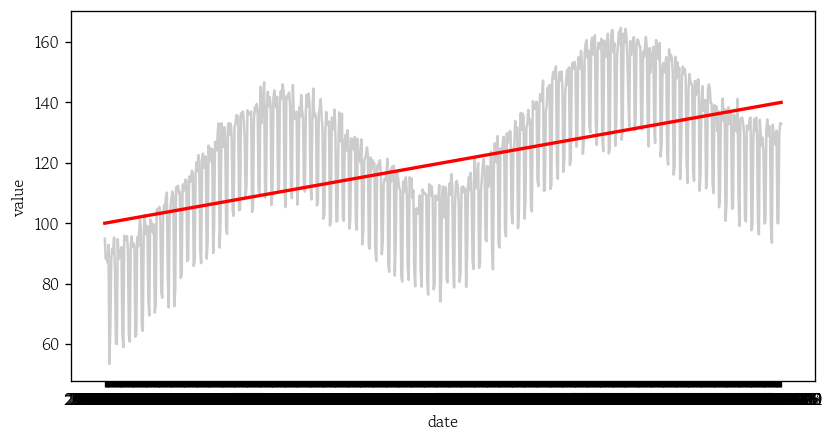

In [14]:
sns.lineplot(data=df, x='date', y='value', color='0.8')
sns.lineplot(x=range(731), y=trend, color='red', linewidth=2)
plt.show()

## 누락 및 중복 시점 생성

In [15]:
# 삭제할 날짜 리스트 생성
drop_dates = ['2024-01-05', '2024-02-10', '2024-03-20']

In [16]:
# 선택한 행 삭저
df = df.loc[~df['date'].isin(drop_dates), :].copy()

In [17]:
# 중복 추가 날짜 시르트 생성
dup_dates = ['2024-01-15', '2024-03-31', '2024-04-25']

In [18]:
# 선택한 행 삭저
dup_rows = df.loc[df['date'].isin(dup_dates), :].copy()

## 가상의 시계열 데이터 변형

In [19]:
# 행 방향으로 결합 후 재할당
df = pd.concat(objs=[df, dup_rows], ignore_index=True)

In [20]:
# 순서를 임의로 섞어 정렬되지 않은 상태로 만들기
df = df.sample(frac=1, random_state=1).reset_index(drop=True)

In [21]:
# 일부 값을 결측으로 처리
df.loc[df.sample(n=5, random_state=1).index, 'value'] = np.nan

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    731 non-null    object 
 1   value   726 non-null    float64
dtypes: float64(1), object(1)
memory usage: 11.6+ KB


## 날짜시간 데이터로 변환

In [23]:
# 날짜시간형으로 변환
df['date'] = pd.to_datetime(arg=df['date'], errors='coerce')

In [24]:
df.dtypes

date     datetime64[ns]
value           float64
dtype: object

In [25]:
# 인덱스 설정 후 오름차순 정렬하여 재할당
df = df.set_index(keys='date').sort_index()

In [26]:
df.head()

,value
date,
2024-01-01,94.87
2024-01-02,88.22
2024-01-03,88.54
2024-01-04,86.97
2024-01-06,53.44


## 날짜 파생변수 생성

In [27]:
df['year'] = df.index.year

In [28]:
df['quarter'] = df.index.quarter

In [29]:
df['month'] = df.index.month

In [30]:
df['day'] = df.index.day

In [31]:
df['dayofweek'] = df.index.day_name(locale='ko_KR')

In [32]:
df['is_weekend'] = (df.index.dayofweek >= 5)

In [33]:
df.head(10)

,value,year,quarter,month,day,dayofweek,is_weekend
date,,,,,,,
2024-01-01,94.87,2024,1,1,1,월요일,False
2024-01-02,88.22,2024,1,1,2,화요일,False
2024-01-03,88.54,2024,1,1,3,수요일,False
2024-01-04,86.97,2024,1,1,4,목요일,False
2024-01-06,53.44,2024,1,1,6,토요일,True
2024-01-07,65.67,2024,1,1,7,일요일,True
2024-01-08,88.24,2024,1,1,8,월요일,False
2024-01-09,91.58,2024,1,1,9,화요일,False
2024-01-10,89.98,2024,1,1,10,수요일,False


In [34]:
df = df.filter(items=['value'])

In [35]:
df.head()

,value
date,
2024-01-01,94.87
2024-01-02,88.22
2024-01-03,88.54
2024-01-04,86.97
2024-01-06,53.44


## 시계열 데이터의 인덱싱 및 슬라이싱

In [36]:
df.loc['2024-01-01', :]

value    94.87
Name: 2024-01-01 00:00:00, dtype: float64

In [37]:
df.loc['2024-01-01':'2024-01-10', :]

,value
date,
2024-01-01,94.87
2024-01-02,88.22
2024-01-03,88.54
2024-01-04,86.97
2024-01-06,53.44
2024-01-07,65.67
2024-01-08,88.24
2024-01-09,91.58
2024-01-10,89.98


In [38]:
df.loc[['2024-01-01', '2025-01-01'], :]

,value
date,
2024-01-01,94.87
2025-01-01,111.60


In [39]:
df.loc[df.index.month == 1, :]

,value
date,
2024-01-01,94.87
2024-01-02,88.22
2024-01-03,88.54
2024-01-04,86.97
2024-01-06,53.44
...,...
2025-01-27,112.17
2025-01-28,115.25
2025-01-29,110.96


## 중복 시점 확인

In [40]:
# 중복 여부 마스크 생성
dup_mask = df.index.duplicated(keep=False)

In [41]:
dup_rows = df.loc[dup_mask]

In [42]:
dup_rows

,value
date,
2024-01-15,94.75
2024-01-15,94.75
2024-03-31,88.10
2024-03-31,88.10
2024-04-25,120.32
2024-04-25,120.32


- 중간에 있는 행 선택
- nth 메서드 괄호안에 정수 인덱스를 지정하면 n+1 번째 행을 반환
    - 0 : first
    - -1 : last
- groupby 메서드의 sort 매개변수에 전달되는 인수는 True여야함

In [ ]:
dup_rows.groupby(dup_rows.index).nth(0)

In [43]:
# 그룹 설정 후 편균 계산하여 재할당
df = df.groupby(df.index)['value'].mean()

## 누락 시점 확인

In [44]:
df.shape

(728,)

In [45]:
# 기대 인덱스 생성 후 할당
full_idx = pd.date_range(df.index.min(), df.index.max())

In [46]:
# 누락된 인덱스를 생성 후 할당
miss_idx = full_idx.difference(df.index)

In [47]:
miss_idx

DatetimeIndex(['2024-01-05', '2024-02-10', '2024-03-20'], dtype='datetime64[ns]', freq=None)

In [48]:
# 누락된 인덱스를 추가 후 재할당
df = df.reindex(index=full_idx)

## 결측값 처리

In [49]:
# 결측행 확인
df.loc[df.isna()]
# 2024-01-05   NaN
# 2024-02-10   NaN
# 2024-03-20   NaN
# 2024-06-15   NaN
# 2024-09-09   NaN
# 2024-12-28   NaN
# 2025-10-10   NaN
# 2025-12-28   NaN
# Name: value, dtype: float64

2024-01-05   NaN
2024-02-10   NaN
2024-03-20   NaN
2024-06-15   NaN
2024-09-09   NaN
2024-12-28   NaN
2025-10-10   NaN
2025-12-28   NaN
Name: value, dtype: float64

In [50]:
df = df.to_frame()
df.index.name = 'date'

In [51]:
df['value_ffill'] = df['value'].ffill()

In [52]:
df['value_linear'] = df['value'].interpolate(method='linear')

In [53]:
df['value_time'] = df['value'].interpolate(method='time')

In [54]:
df.loc['2024-01-04':'2024-01-10', :]

,value,value_ffill,value_linear,value_time
date,,,,
2024-01-04,86.97,86.97,86.970,86.970
2024-01-05,NaN,86.97,70.205,70.205
2024-01-06,53.44,53.44,53.440,53.440
2024-01-07,65.67,65.67,65.670,65.670
2024-01-08,88.24,88.24,88.240,88.240
2024-01-09,91.58,91.58,91.580,91.580
2024-01-10,89.98,89.98,89.980,89.980


In [55]:
sr = pd.Series(data=[1, 2, np.nan, 6, 7])
sr.index = pd.date_range('2026-01-01', '2026-01-05')

In [56]:
sr.interpolate(method='linear')

2026-01-01    1.0
2026-01-02    2.0
2026-01-03    4.0
2026-01-04    6.0
2026-01-05    7.0
Freq: D, dtype: float64

In [57]:
sr.index = pd.to_datetime(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-06', '2026-01-07'])

In [58]:
sr.interpolate(method='time')

2026-01-01    1.0
2026-01-02    2.0
2026-01-03    3.0
2026-01-06    6.0
2026-01-07    7.0
dtype: float64

In [59]:
df.columns

Index(['value', 'value_ffill', 'value_linear', 'value_time'], dtype='object')

In [ ]:
# 불필요한 컬럼 모두 삭제
df = df.drop(columns=['value', 'value_ffill', 'value_time'])

In [ ]:
# 남은 열이름 변경
df = df.rename(columns={'value_linear': 'value'})

In [63]:
df.head()

,value
date,
2024-01-01,94.870
2024-01-02,88.220
2024-01-03,88.540
2024-01-04,86.970
2024-01-05,70.205


## 시차 변수 생성

In [64]:
# 아래로 값 이동
df['lag_1'] = df['value'].shift(periods=1)
df['lag_2'] = df['value'].shift(periods=2)
df['lag_3'] = df['value'].shift(periods=3)

In [66]:
df.head()

,value,lag_1,lag_2,lag_3
date,,,,
2024-01-01,94.870,NaN,NaN,NaN
2024-01-02,88.220,94.87,NaN,NaN
2024-01-03,88.540,88.22,94.87,NaN
2024-01-04,86.970,88.54,88.22,94.87
2024-01-05,70.205,86.97,88.54,88.22


In [67]:
df.corr()

,value,lag_1,lag_2,lag_3
value,1.000000,0.741733,0.500162,0.499909
lag_1,0.741733,1.000000,0.741645,0.500052
lag_2,0.500162,0.741645,1.000000,0.741595
lag_3,0.499909,0.500052,0.741595,1.000000


## 이동 평균 계산

In [68]:
df['roll_7_avg'] = df['value'].rolling(window=7, min_periods=1).mean()
df['roll_7_std'] = df['value'].rolling(window=7, min_periods=1).std()

In [69]:
df.head()

,value,lag_1,lag_2,lag_3,roll_7_avg,roll_7_std
date,,,,,,
2024-01-01,94.870,NaN,NaN,NaN,94.870000,NaN
2024-01-02,88.220,94.87,NaN,NaN,91.545000,4.702260
2024-01-03,88.540,88.22,94.87,NaN,90.543333,3.750418
2024-01-04,86.970,88.54,88.22,94.87,89.650000,3.545316
2024-01-05,70.205,86.97,88.54,88.22,85.761000,9.222177


In [70]:
df['expand_avg'] = df['value'].expanding().mean()

In [71]:
df.head(10)

,value,lag_1,lag_2,lag_3,roll_7_avg,roll_7_std,expand_avg
date,,,,,,,
2024-01-01,94.870,NaN,NaN,NaN,94.870000,NaN,94.870000
2024-01-02,88.220,94.870,NaN,NaN,91.545000,4.702260,91.545000
2024-01-03,88.540,88.220,94.870,NaN,90.543333,3.750418,90.543333
2024-01-04,86.970,88.540,88.220,94.870,89.650000,3.545316,89.650000
2024-01-05,70.205,86.970,88.540,88.220,85.761000,9.222177,85.761000
2024-01-06,53.440,70.205,86.970,88.540,80.374167,15.561063,80.374167
2024-01-07,65.670,53.440,70.205,86.970,78.273571,15.253734,78.273571
2024-01-08,88.240,65.670,53.440,70.205,77.326429,14.222442,79.519375
2024-01-09,91.580,88.240,65.670,53.440,77.806429,14.700050,80.859444


## 변화량 기반 변수 생성

In [ ]:
# 전일 대비 차분 계산
df['diff_1'] = df['value'].diff(periods=1)

In [73]:
df.head()

,value,lag_1,lag_2,lag_3,roll_7_avg,roll_7_std,expand_avg,diff_1
date,,,,,,,,
2024-01-01,94.870,NaN,NaN,NaN,94.870000,NaN,94.870000,NaN
2024-01-02,88.220,94.87,NaN,NaN,91.545000,4.702260,91.545000,-6.650
2024-01-03,88.540,88.22,94.87,NaN,90.543333,3.750418,90.543333,0.320
2024-01-04,86.970,88.54,88.22,94.87,89.650000,3.545316,89.650000,-1.570
2024-01-05,70.205,86.97,88.54,88.22,85.761000,9.222177,85.761000,-16.765


In [74]:
# 전일 대비 증감률 계산
df['pent_1'] = df['value'].pct_change(periods=1)

In [75]:
df.head()

,value,lag_1,lag_2,lag_3,roll_7_avg,roll_7_std,expand_avg,diff_1,pent_1
date,,,,,,,,,
2024-01-01,94.870,NaN,NaN,NaN,94.870000,NaN,94.870000,NaN,NaN
2024-01-02,88.220,94.87,NaN,NaN,91.545000,4.702260,91.545000,-6.650,-0.070096
2024-01-03,88.540,88.22,94.87,NaN,90.543333,3.750418,90.543333,0.320,0.003627
2024-01-04,86.970,88.54,88.22,94.87,89.650000,3.545316,89.650000,-1.570,-0.017732
2024-01-05,70.205,86.97,88.54,88.22,85.761000,9.222177,85.761000,-16.765,-0.192768


In [76]:
df = df.filter(like='value')

In [77]:
df.head()

,value
date,
2024-01-01,94.870
2024-01-02,88.220
2024-01-03,88.540
2024-01-04,86.970
2024-01-05,70.205


## 시간 단위 재구성

In [78]:
df.loc['2024-01-01':'2024-01-07', 'value'].sum()

547.915

In [ ]:
# 주 단위로 합계 계산
df.resample(rule='W-SUN')['value'].sum()

date
2024-01-07    547.915
2024-01-14    569.990
2024-01-21    578.090
2024-01-28    596.180
2024-02-04    592.340
               ...   
2025-12-07    854.630
2025-12-14    840.530
2025-12-21    849.590
2025-12-28    862.245
2026-01-04    395.500
Freq: W-SUN, Name: value, Length: 105, dtype: float64

In [80]:
# 주 단위 합계 4주 이동 평균 계산
df.resample(rule='W-SUN')['value'].sum().rolling(window=4).mean()

date
2024-01-07          NaN
2024-01-14          NaN
2024-01-21          NaN
2024-01-28    573.04375
2024-02-04    584.15000
                ...    
2025-12-07    866.69250
2025-12-14    856.35000
2025-12-21    851.52500
2025-12-28    851.74875
2026-01-04    736.96625
Freq: W-SUN, Name: value, Length: 105, dtype: float64

In [ ]:
# 특정 요일 선택하여 반환
df.asfreq(freq='W-FRI')

,value
date,
2024-01-05,70.205
2024-01-12,84.780
2024-01-19,92.070
2024-01-26,91.140
2024-02-02,92.650
...,...
2025-11-28,135.020
2025-12-05,129.110
2025-12-12,123.100


## 가상의 시계열 데이터 시각화

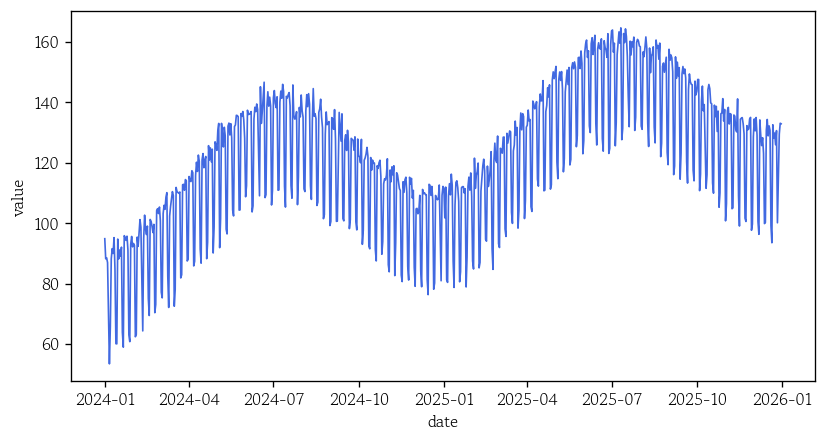

In [83]:
sns.lineplot(x=df.index, y=df['value'], color='royalblue', linewidth=1)
plt.show()

## 시계열 분해

In [84]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [85]:
result = seasonal_decompose(x=df['value'], model='additive', period=7)

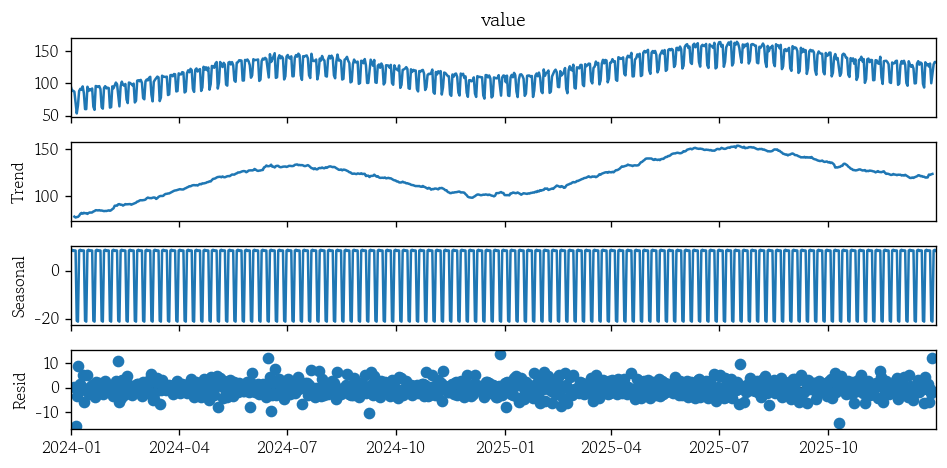

In [86]:
result.plot();

## 외부 파일로 저장

In [87]:
os.getcwd()

'/Users/taehyunan/Desktop/Repo/SeSAC/Study/sesac_ml_dl_study_repo/project/code/time_series'

In [88]:
os.chdir('../../data')

In [89]:
df.to_pickle(path='Synthetic_Time_Series.pkl')